# Climate Debt Analysis: Bangladesh Master Pipeline

This notebook executes a comprehensive 3-stage data analysis pipeline connecting **Bangladesh's subnational rainfall anomalies**, **food price volatility**, and **macro-level external debt**.

### Pipeline Structure:
1. **Stage 1: Individual EDA** - Baseline patterns and clustering.
2. **Stage 2: Pairwise Alignment** - Cross-pillar correlations and causality.
3. **Stage 3: Joint Mediation** - The causal mechanism (Rainfall -> Food -> Debt).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
import os

# Settings
sns.set(style="whitegrid")
os.makedirs('production_artifacts', exist_ok=True)

PCODE_MAP = {
    'BD10': 'Barisal', 'BD20': 'Chittagong', 'BD30': 'Dhaka', 
    'BD40': 'Khulna', 'BD50': 'Rajshahi', 'BD55': 'Rangpur', 
    'BD60': 'Sylhet', 'BD45': 'Mymensingh'
}

## Stage 1: Individual Dataset EDA
We start by analyzing the baseline behavior of each pillar independently.

In [7]:
# Load Data
rf_df = pd.read_csv('datasets/bgd-rainfall-subnat-full.csv')
food_df = pd.read_csv('datasets/wfp_food_prices_bgd.csv')
debt_df = pd.read_csv('datasets/external-debt_bgd.csv')

rf_df['date'] = pd.to_datetime(rf_df['date'])
food_df['date'] = pd.to_datetime(food_df['date'])

print("Datasets Loaded Successfully.")

Datasets Loaded Successfully.


### Rainfall Clustering (Regions)
Identify which regions are most prone to rainfall anomalies (floods/droughts).

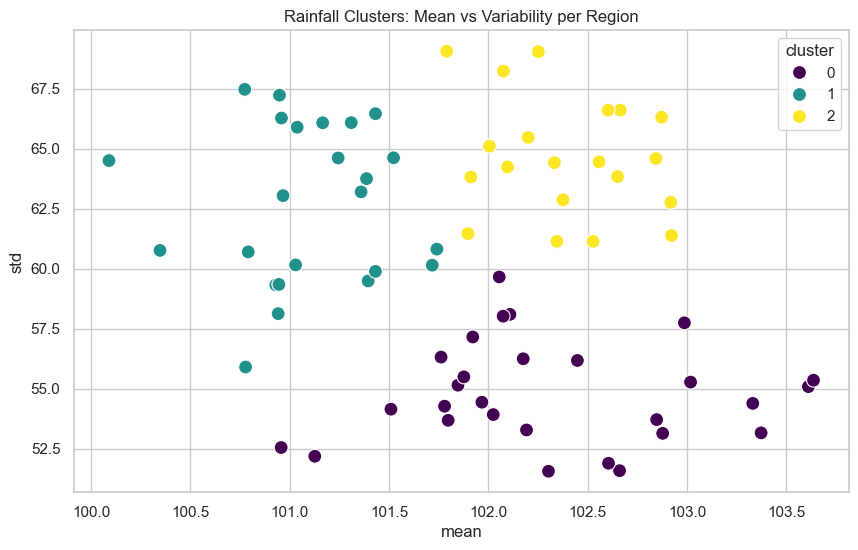

In [8]:
region_stats = rf_df.groupby('PCODE')['rfq'].agg(['mean', 'std']).reset_index()
scaler = StandardScaler()
X_cluster = scaler.fit_transform(region_stats[['mean', 'std']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
region_stats['cluster'] = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=region_stats, x='mean', y='std', hue='cluster', palette='viridis', s=100)
plt.title('Rainfall Clusters: Mean vs Variability per Region')
plt.show()

## Stage 2: Pairwise Alignment
Establishing the links: Climate shock -> Food prices and Food vulnerability -> Debt.

Aligned Rainfall/Food Samples: 1645


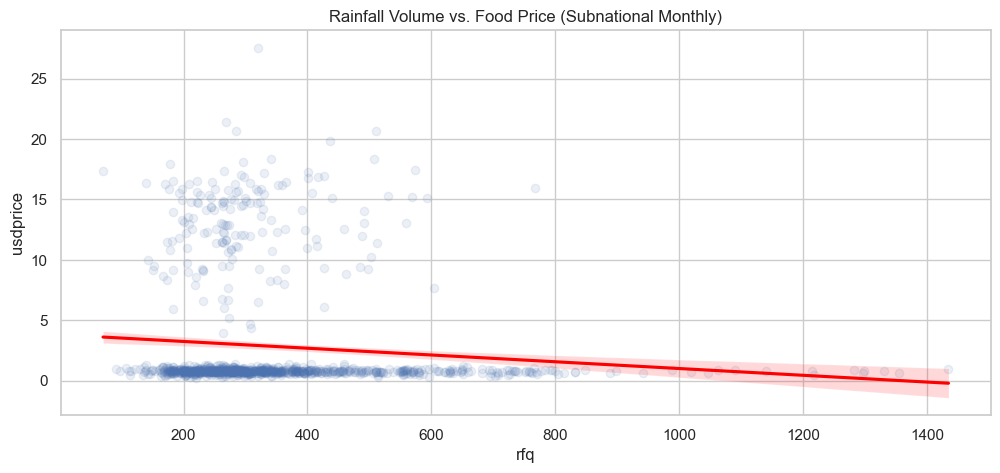

In [9]:
# rainfall vs food
rf_df['admin1'] = rf_df['PCODE'].map(PCODE_MAP)
monthly_rf = rf_df.groupby([rf_df['date'].dt.year, rf_df['date'].dt.month, 'admin1'])['rfq'].sum().rename_axis(['year', 'month', 'admin1']).reset_index()
monthly_food = food_df.groupby([food_df['date'].dt.year, food_df['date'].dt.month, 'admin1'])['usdprice'].mean().rename_axis(['year', 'month', 'admin1']).reset_index()

merged_ab = pd.merge(monthly_food, monthly_rf, on=['year', 'month', 'admin1'])
print(f"Aligned Rainfall/Food Samples: {len(merged_ab)}")

plt.figure(figsize=(12, 5))
sns.regplot(data=merged_ab.sample(min(1000, len(merged_ab))), x='rfq', y='usdprice', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Rainfall Volume vs. Food Price (Subnational Monthly)')
plt.show()

## Stage 3: Joint Mediation Analysis
Executing the Baron-Kenny test to prove the mechanism: Rainfall -> Food Price -> External Debt.

In [10]:
# Prepare Annual Master Dataset
annual_rf = rf_df.groupby(rf_df['date'].dt.year)['rfq'].sum().reset_index().rename(columns={'date':'year', 'rfq':'annual_rfq'})
annual_food = food_df.groupby(food_df['date'].dt.year)['usdprice'].std().reset_index().rename(columns={'date':'year', 'usdprice':'food_volatility'})
debt_stock = debt_df[debt_df['Indicator Name'].str.contains('External debt stocks, total', case=False)].copy()
debt_stock['debt_growth'] = debt_stock['Value'].pct_change()
debt_stock = debt_stock.rename(columns={'Year':'year'})

master_df = pd.merge(pd.merge(annual_rf, annual_food, on='year'), debt_stock[['year', 'debt_growth']], on='year').dropna()

# Mediation Test (OLS)
X = sm.add_constant(master_df['annual_rfq'])
M = master_df['food_volatility']
Y = master_df['debt_growth']

model_total = sm.OLS(Y, X).fit()
model_path_a = sm.OLS(M, X).fit()
model_full = sm.OLS(Y, sm.add_constant(pd.concat([master_df['annual_rfq'], M], axis=1))).fit()

print("--- MEDIATION RESULTS ---")
print(f"Total Effect P-val: {model_total.pvalues['annual_rfq']:.4f}")
print(f"Path A (Rain -> Food) P-val: {model_path_a.pvalues['annual_rfq']:.4f}")
print(f"Path B (Food -> Debt) P-val: {model_full.pvalues['food_volatility']:.4f}")

--- MEDIATION RESULTS ---
Total Effect P-val: 0.2841
Path A (Rain -> Food) P-val: 0.4711
Path B (Food -> Debt) P-val: 0.0530


### Risk Era Clustering
Categorizing years into Risk Profiles based on all three dimensions.

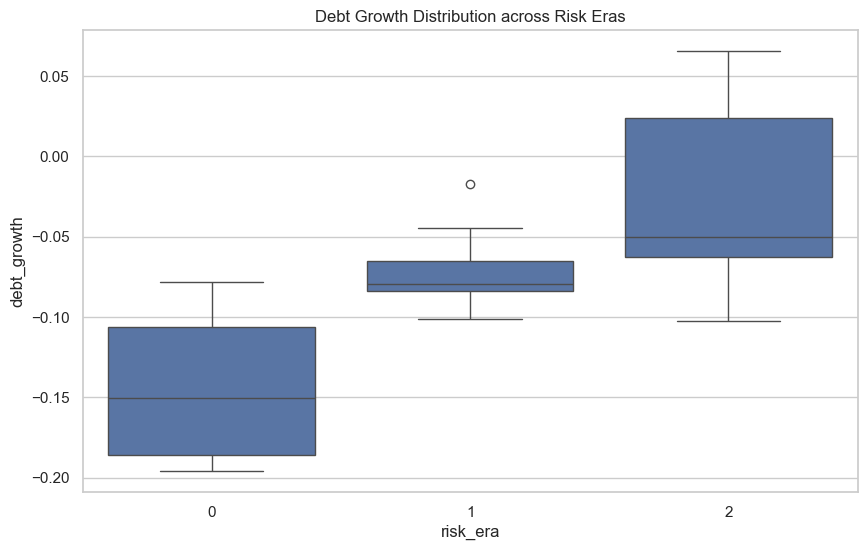

In [11]:
features = ['annual_rfq', 'food_volatility', 'debt_growth']
X_scaled = scaler.fit_transform(master_df[features])
master_df['risk_era'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.boxplot(data=master_df, x='risk_era', y='debt_growth')
plt.title('Debt Growth Distribution across Risk Eras')
plt.show()